In [3]:
import sqlite3
import json
import os

# Path to your database
DB_PATH = 'db/results.sqlite'

def verify_database_integrity():
    print(f"Checking database: {DB_PATH}...\n")
    
    # 1. File Existence Check
    if not os.path.exists(DB_PATH):
        print(f"❌ File not found: {DB_PATH}. Run an experiment first!")
        return
    
    try:
        conn = sqlite3.connect(DB_PATH)
        conn.row_factory = sqlite3.Row
        
        # 2. Fetch the most recent result
        cursor = conn.execute("SELECT * FROM Results ORDER BY result_id DESC LIMIT 1")
        row = cursor.fetchone()
        
        if row is None:
            print("❌ Database exists but is empty! Run an experiment first.")
            return

        print(f"✅ Connection successful. Inspecting Result ID: {row['result_id']}\n")

        # Get list of actual columns present in the DB
        actual_columns = list(row.keys())

        # --- CHECK 1: OLD DATA (Scalars & Text) ---
        print("--- [1/3] Verifying Legacy Data ---")
        old_keys = ['uq_mech_score', 'uq_avg_entropy', 'full_trace_text', 'predicted_answer']
        
        all_old_ok = True
        for key in old_keys:
            if key not in actual_columns:
                print(f"  ❌ CRITICAL: Legacy column '{key}' is MISSING from schema!")
                all_old_ok = False
                continue

            val = row[key]
            if val is not None and str(val).strip() != "":
                # Truncate for cleaner display
                disp = str(val).replace('\n', ' ')
                if len(disp) > 50: disp = disp[:47] + "..."
                print(f"  ✅ {key}: {disp}")
            else:
                print(f"  ❌ {key} is NULL or EMPTY!")
                all_old_ok = False
        
        # --- CHECK 2: NEW DATA (Traces, Tokens & Counts) ---
        print("\n--- [2/3] Verifying New Token-Level Data ---")
        # Now includes 'uq_tokens'
        new_keys = ['uq_mech_trace', 'uq_entropy_trace', 'uq_logit_gap_trace', 'uq_tokens', 'gen_len']
        
        # A. Schema Check (Prevent IndexErrors)
        missing_new_cols = [k for k in new_keys if k not in actual_columns]
        if missing_new_cols:
            print(f"  ❌ SCHEMA ERROR: Missing new columns: {missing_new_cols}")
            print("     -> SOLUTION: Delete db/results.sqlite and re-run run_experiment.py")
            return # Stop here, cannot check values
        else:
            print("  ✅ Schema Check: All new columns exist.")

        # B. Value Check
        all_new_ok = True
        gen_len_val = row['gen_len']

        # Check gen_len integrity
        if isinstance(gen_len_val, int) and gen_len_val > 0:
             print(f"  ✅ gen_len: {gen_len_val} (Integer)")
        else:
            print(f"  ❌ gen_len: Invalid integer ({gen_len_val})")
            all_new_ok = False

        # Check JSON Traces
        trace_keys = ['uq_mech_trace', 'uq_entropy_trace', 'uq_logit_gap_trace', 'uq_tokens']
        for key in trace_keys:
            val = row[key]
            try:
                if val is None:
                    print(f"  ❌ {key}: Value is NULL.")
                    all_new_ok = False
                    continue

                parsed = json.loads(val)
                
                if not isinstance(parsed, list):
                    print(f"  ❌ {key}: Parsed JSON is not a list (got {type(parsed)}).")
                    all_new_ok = False
                    continue
                
                if len(parsed) == 0:
                    print(f"  ⚠️ {key}: List is empty.")
                else:
                    # Formatting logic for display (string vs float)
                    if key == 'uq_tokens':
                        # Clean up token string for display (e.g. remove unicode G)
                        first_item = str(parsed[0]).replace('Ġ', '')
                        sample = f"\"{first_item}\""
                    else:
                        sample = f"{parsed[0]:.4f}"
                        
                    print(f"  ✅ {key}: List with {len(parsed)} items. First: {sample}")
                    
                    # Consistency Check
                    if len(parsed) != gen_len_val:
                        print(f"     ⚠️ Mismatch: len({key})={len(parsed)} vs gen_len={gen_len_val}")
            
            except json.JSONDecodeError:
                print(f"  ❌ {key}: Malformed JSON string.")
                all_new_ok = False

        # --- CHECK 3: CONCLUSION ---
        print("\n" + "="*40)
        if all_old_ok and all_new_ok:
            print("🎉 SUCCESS: Database schema is updated and all fields are logging correctly!")
            print("   You are ready to run the Attribution Spike Visualization.")
        else:
            print("⚠️ ISSUES DETECTED: See errors above.")
            
    except sqlite3.OperationalError as e:
        print(f"❌ SQL Error: {e}")
    finally:
        if 'conn' in locals(): conn.close()

# Run the check
verify_database_integrity()

Checking database: db/results.sqlite...

✅ Connection successful. Inspecting Result ID: 4

--- [1/3] Verifying Legacy Data ---
  ✅ uq_mech_score: 0.9526801215277778
  ✅ uq_avg_entropy: 0.026095036334461637
  ✅ full_trace_text:  To determine the total number of clips Natalia...
  ✅ predicted_answer: 72

--- [2/3] Verifying New Token-Level Data ---
  ✅ Schema Check: All new columns exist.
  ✅ gen_len: 180 (Integer)
  ✅ uq_mech_trace: List with 180 items. First: 0.9746
  ✅ uq_entropy_trace: List with 180 items. First: 0.6367
  ✅ uq_logit_gap_trace: List with 180 items. First: 0.6920
  ✅ uq_tokens: List with 180 items. First: "To"

🎉 SUCCESS: Database schema is updated and all fields are logging correctly!
   You are ready to run the Attribution Spike Visualization.


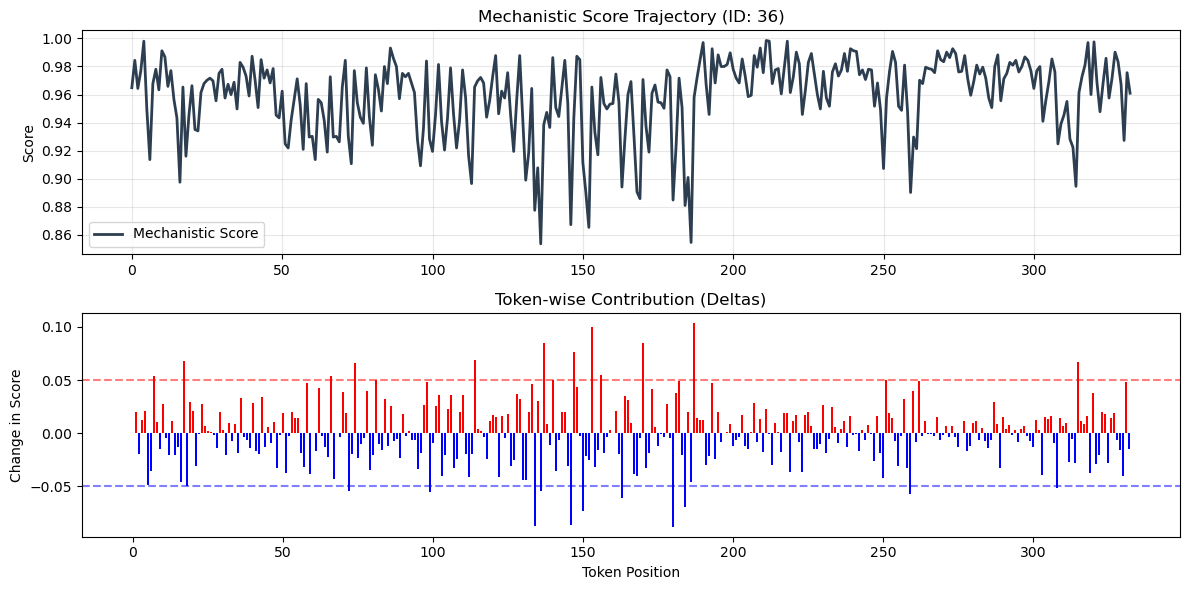


=== MAJOR SPIKES (> 0.05) ===
Pos   | Delta    | Score    | Token
---------------------------------------------
7     | +0.0542 🔺 | 0.9678   | " the"
17    | +0.0679 🔺 | 0.9653   | " she"
66    | +0.0537 🔺 | 0.9727   | "3"
72    | -0.0542 🔻 | 0.9302   | ":"
74    | +0.0664 🔺 | 0.9771   | "1"
81    | +0.0503 🔺 | 0.9741   | "1"
99    | -0.0557 🔻 | 0.9282   | "6"
114   | +0.0688 🔺 | 0.9653   | "]\n\n"
134   | -0.0869 🔻 | 0.8774   | "6"
136   | -0.0542 🔻 | 0.8535   | "\"
137   | +0.0850 🔺 | 0.9385   | "]\n"
146   | -0.0864 🔻 | 0.8672   | " ="
147   | +0.0762 🔺 | 0.9434   | " "
150   | -0.0732 🔻 | 0.9116   | "4"
153   | +0.1001 🔺 | 0.9653   | "]\n"
156   | +0.0552 🔺 | 0.9722   | "1"
163   | -0.0605 🔻 | 0.8940   | " ="
170   | +0.0850 🔺 | 0.9707   | "]\n"
180   | -0.0879 🔻 | 0.8848   | " ="
184   | -0.0698 🔻 | 0.8809   | "3"
187   | +0.1035 🔺 | 0.9580   | "]\n\n"
251   | +0.0503 🔺 | 0.9575   | " -"
259   | -0.0576 🔻 | 0.8901   | "4"
308   | -0.0513 🔻 | 0.9248   | "3"
315   | +0.0669 🔺 | 0.9

In [5]:
import sqlite3
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- CONFIG ---
DB_PATH = 'db/results.sqlite'
THRESHOLD = 0.05  # Highlight jumps larger than this (positive or negative)

def analyze_trace_spikes(result_id=None):
    conn = sqlite3.connect(DB_PATH)
    conn.row_factory = sqlite3.Row
    
    # 1. Fetch Data
    if result_id:
        query = "SELECT * FROM Results WHERE result_id = ?"
        params = (result_id,)
    else:
        query = "SELECT * FROM Results ORDER BY result_id DESC LIMIT 1"
        params = ()
        
    row = conn.execute(query, params).fetchone()
    conn.close()
    
    if not row:
        print("No data found.")
        return

    # 2. Parse JSON Traces
    try:
        mech_trace = json.loads(row['uq_mech_trace'])
        tokens = json.loads(row['uq_tokens']) # <--- NOW USING REAL TOKENS
        
        # Optional: Load others if needed
        # entropy_trace = json.loads(row['uq_entropy_trace'])
    except TypeError:
        print(f"Result {row['result_id']} does not have trace data (Legacy row?).")
        return
    except KeyError:
        print(f"Result {row['result_id']} is missing 'uq_tokens'. Did you run the schema update?")
        return

    # 3. Calculate Deltas (Spikes)
    # Delta[i] = Score[i] - Score[i-1]
    deltas = [0] + [mech_trace[i] - mech_trace[i-1] for i in range(1, len(mech_trace))]
    
    # 4. Visualization: The "Spike Graph"
    plt.figure(figsize=(12, 6))
    
    # Plot Raw Score
    plt.subplot(2, 1, 1)
    plt.plot(mech_trace, label='Mechanistic Score', color='#2c3e50', linewidth=2)
    plt.title(f"Mechanistic Score Trajectory (ID: {row['result_id']})")
    plt.ylabel("Score")
    plt.grid(True, alpha=0.3)
    plt.legend()
    
    # Plot Deltas (The Spikes)
    plt.subplot(2, 1, 2)
    plt.bar(range(len(deltas)), deltas, color=['red' if d > 0 else 'blue' for d in deltas])
    plt.axhline(y=THRESHOLD, color='r', linestyle='--', alpha=0.5)
    plt.axhline(y=-THRESHOLD, color='b', linestyle='--', alpha=0.5)
    plt.title("Token-wise Contribution (Deltas)")
    plt.ylabel("Change in Score")
    plt.xlabel("Token Position")
    plt.tight_layout()
    plt.show()

    # 5. Text Alignment (Exact)
    print(f"\n=== MAJOR SPIKES (> {THRESHOLD}) ===")
    print(f"{'Pos':<5} | {'Delta':<8} | {'Score':<8} | {'Token'}")
    print("-" * 45)
    
    # Use the minimum length to avoid index errors if traces slightly mismatch (though they shouldn't now)
    limit = min(len(tokens), len(deltas))
    
    for i in range(limit):
        if abs(deltas[i]) >= THRESHOLD:
            indicator = "🔺" if deltas[i] > 0 else "🔻"
            
            # Clean up special token characters for readability
            # 'Ġ' is used by BPE (RoBERTa/GPT) to represent space
            # 'Ċ' represents newline
            token_str = str(tokens[i]).replace('Ġ', ' ').replace('Ċ', '\\n')
            
            print(f"{i:<5} | {deltas[i]:+.4f} {indicator} | {mech_trace[i]:.4f}   | \"{token_str}\"")

# --- RUN IT ---
# Analyze the most recent generation
analyze_trace_spikes()